In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(1599.5), np.float64(1199.5), np.float64(-0.5))

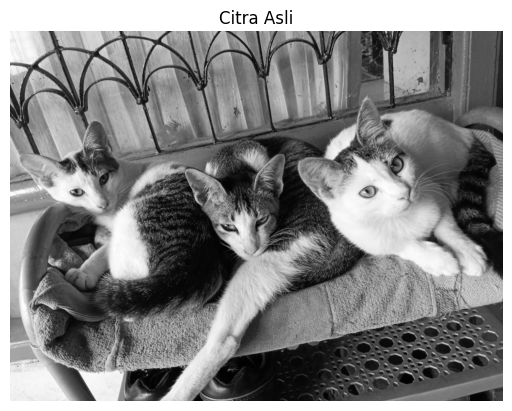

In [2]:
img = Image.open("gambar.jpg").convert("L")
img_array = np.array(img)

plt.imshow(img_array, cmap='gray')
plt.title("Citra Asli")
plt.axis('off')

In [3]:
kernel = np.ones((5,5)) / 25
print(kernel)

[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


In [4]:
h, w = img_array.shape
output1 = img_array.copy()

for i in range(2, h-2):
    for j in range(2, w-2):

        total = 0

        for m in range(-2,3):
            for n in range(-2,3):

                total += img_array[i+m][j+n] * kernel[m+2][n+2]

        output1[i][j] = total

In [5]:
pad = 2
padded = np.pad(img_array, pad, mode='constant', constant_values=0)

output2 = np.zeros_like(img_array)

for i in range(img_array.shape[0]):
    for j in range(img_array.shape[1]):

        total = 0

        for m in range(5):
            for n in range(5):

                total += padded[i+m][j+n] * kernel[m][n]

        output2[i][j] = total

In [6]:
padded2 = np.pad(img_array, 2, mode='edge')

output3 = np.zeros_like(img_array)

for i in range(img_array.shape[0]):
    for j in range(img_array.shape[1]):

        total = 0

        for m in range(5):
            for n in range(5):

                total += padded2[i+m][j+n] * kernel[m][n]

        output3[i][j] = total

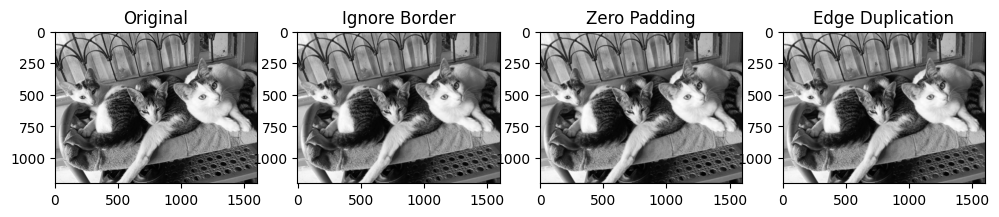

In [7]:
plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(img_array, cmap='gray')
plt.title("Original")

plt.subplot(1,4,2)
plt.imshow(output1, cmap='gray')
plt.title("Ignore Border")

plt.subplot(1,4,3)
plt.imshow(output2, cmap='gray')
plt.title("Zero Padding")

plt.subplot(1,4,4)
plt.imshow(output3, cmap='gray')
plt.title("Edge Duplication")

plt.show()